$$
\begin{array}{l}
\quad\quad\quad \textbf{I consider the 2 Years (2Y) Bond Yield because the market Interest rate expectations} \\
\quad\quad\quad \textbf{trigger the bond price moves and when bond price is up the yield is down, if bond price} \\
\quad\quad\quad \textbf{is down the yield is up}, \text{ bond prices move because of buying and selling in the market.} \\[1em]
\quad\quad\quad \text{Interest rates are a primary driver of currency prices because they dictate the flow of global} \\
\quad\quad\quad \text{capital, acting as a reward for investors and a cost for borrowers. Generally, } \textbf{higher interest} \\
\quad\quad\quad \textbf{rates strengthen a currency}, \text{ while lower interest rates weaken it. Currency rates react more} \\
\quad\quad\quad \text{to the expectations of the future rates than to the current ones.} \\[1em]
\quad\quad\quad \text{The 2Y yield reflects in real time } \textbf{what the market expects} \text{ central banks to do in the next 2} \\
\quad\quad\quad \text{years.} \\[1em]
\quad\quad\quad \text{So, the point is to measure the } \textbf{change in the 2Y yields} \text{ and not the level and the } \textbf{spread} \\
\quad\quad\quad \textbf{between the US one and the German one} \text{ (the German 2Y yield is the most important for the} \\
\quad\quad\quad \text{euro currency). And we must check if the move in this spread (} \textbf{widening or narrowing} \text{)} \\
\quad\quad\quad \text{reflects in a move of the EURUSD rate.} \\[1em]
\quad\quad\quad \text{In this purpose it is wise to } \textbf{normalize the data before analysis}. \text{ The economic data and} \\
\quad\quad\quad \text{political events that move the yields can be represented on a weekly basis for this reason I} \\
\quad\quad\quad \text{have chosen to average the data with a } \textbf{5 days Mobile Average}. \\[1em]
\quad\quad\quad \text{I will check to confirm any } \textbf{correlation between spread moves and EURUSD moves}. \\[2em]
\quad\quad\quad \textbf{Detailed representation of the 2 years yields importance} \\[1em]
\quad\quad\quad \textbf{The 2Y yield changes:} \\[1em]
\quad\quad\quad - \ \textbf{Continuously} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{During market hours (like a stock)} \\[1em]
\quad\quad\quad - \ \textbf{Abruptly (key moments)} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Economic indicators releases (scheduled)} \\
\quad\quad\quad\quad \bullet \ \text{Central bank announcements (scheduled)} \\
\quad\quad\quad\quad \bullet \ \text{Unexpected news (unscheduled)} \\[1em]
\quad\quad\quad - \ \text{At } \textbf{specific times} \text{, yields can move } \textbf{VERY fast:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Inflation (CPI, Core PCE)} \\
\quad\quad\quad\quad \bullet \ \text{Jobs (NFP, unemployment)} \\
\quad\quad\quad\quad \bullet \ \text{GDP} \\[1em]
\quad\quad\quad \textbf{Example:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Strong US inflation } \rightarrow \text{ Fed may hike } \rightarrow \ \textbf{US 2Y} \uparrow \\
\quad\quad\quad\quad \bullet \ \text{Weak data } \rightarrow \text{ cuts expected } \rightarrow \ \textbf{US 2Y} \downarrow \\[0.5em]
\quad\quad\quad \text{These happen at } \textbf{exact release times} \text{ (e.g., 14:30 CET for US data)} \\[2em]
\quad\quad\quad \textbf{Other determing factors for the 2Y Yield:} \\[1em]
\quad\quad\quad \textbf{Central bank communication} \\[0.5em]
\quad\quad\quad \text{Huge impact when:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Fed / ECB } \textbf{rate decisions} \\
\quad\quad\quad\quad \bullet \ \text{Speeches from central bankers} \\[0.5em]
\quad\quad\quad \text{One sentence can move the 2Y instantly} \\[1.5em]
\quad\quad\quad \textbf{Market sentiment / risk} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Crisis } \rightarrow \text{ investors buy bonds } \rightarrow \text{ yield } \downarrow \\
\quad\quad\quad\quad \bullet \ \text{Risk-on } \rightarrow \text{ sell bonds } \rightarrow \text{ yield } \uparrow \\[1.5em]
\end{array}
$$

In [2]:
# Analysis of the relation SPREAD 2Y Yields and the FX Rate EUR/USD
# We will try to see whether there is some correlation and how it is move and the degree of it 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

In [3]:
spread = pd.read_csv("data/US_DE_2Y_spread.csv")
eurusd = pd.read_csv("data/EURUSD_worked.csv")

In [4]:
eurusd.columns = ["Date", "EURUSD"]
spread["Date"] = pd.to_datetime(spread["Date"])
eurusd["Date"] = pd.to_datetime(eurusd["Date"])
eurusd["EURUSD"]=eurusd["EURUSD"].astype(float)
# to assure the same date format for the boths datasets
for dts in [spread, eurusd]:
    dts["Date"]=pd.to_datetime(dts["Date"])

In [5]:
# merge the two datasets
ds_merged=pd.merge(spread, eurusd, on="Date", how="inner")
ds_merged=ds_merged.sort_values("Date").reset_index(drop=True)

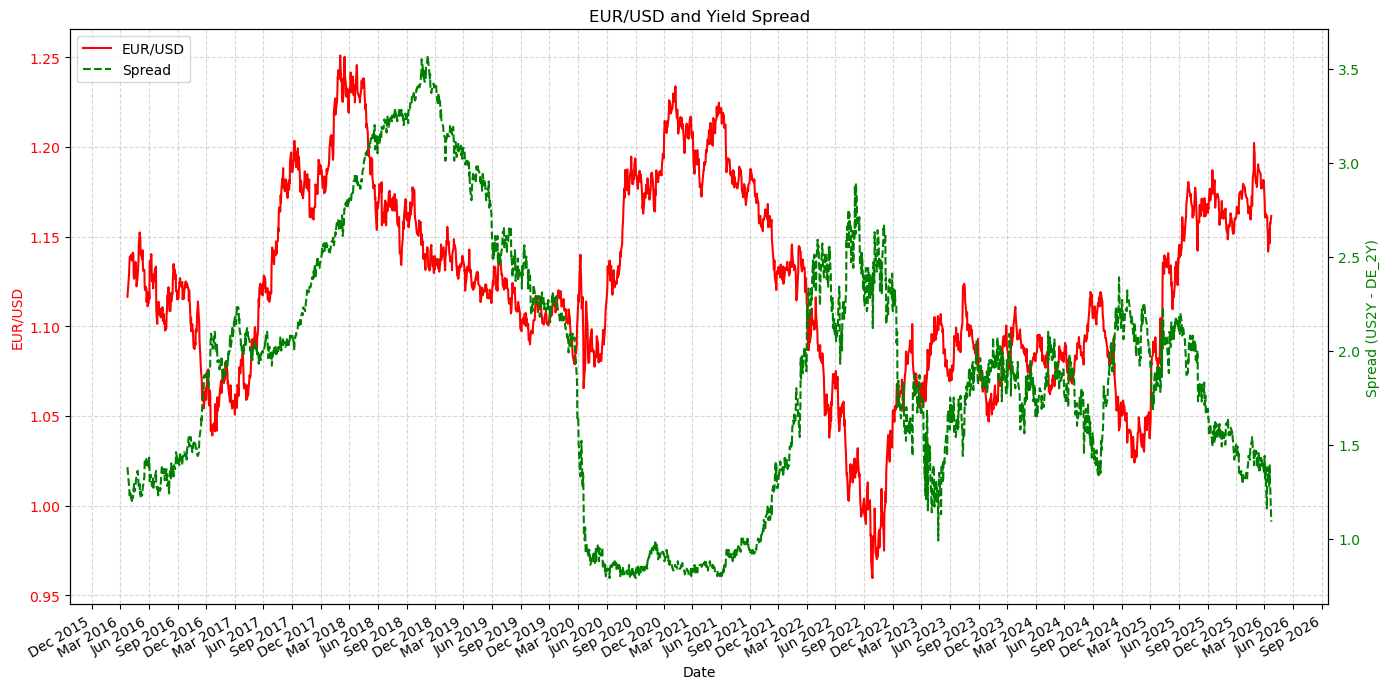

In [6]:

# Create figure
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(ds_merged["Date"], ds_merged["EURUSD"], color="red", linewidth=1.5, label="EUR/USD")
ax1.set_xlabel("Date")
ax1.set_ylabel("EUR/USD", color='red')
ax1.tick_params(axis="y", labelcolor='red')

# The data is displayed at three-month intervals to improve readability on the x-axis.
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax2=ax1.twinx()
ax2.plot(ds_merged["Date"], ds_merged["Spread"], color="green", linestyle="--", linewidth=1.5, label="Spread")
# Right axis: Spread
ax2.set_ylabel("Spread (US2Y - DE_2Y)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("EUR/USD and Yield Spread")
ax1.grid(True, linestyle="--", alpha=0.5)

lines1,labels1=ax1.get_legend_handles_labels()
lines2, labels2=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [7]:
ds_merged["EURUSD"].corr(ds_merged["Spread"])

np.float64(-0.15287533944530796)

In [8]:
ds_merged

,Date,US_2Y,DE_2Y,Spread,EURUSD
0,2016-03-24,0.89,-0.49,1.38,1.11644
1,2016-03-29,0.78,-0.50,1.28,1.12892
2,2016-03-30,0.76,-0.49,1.25,1.13327
3,2016-03-31,0.73,-0.50,1.23,1.13785
4,2016-04-01,0.76,-0.49,1.25,1.13899
...,...,...,...,...,...
2445,2026-03-17,3.68,2.38,1.30,1.15387
2446,2026-03-18,3.76,2.37,1.39,1.14632
2447,2026-03-19,3.79,2.51,1.28,1.15763
2448,2026-03-20,3.88,2.62,1.26,1.15694


$$
\begin{array}{l}
\quad\quad\quad \text{The correlation between the yield spread and the EUR/USD exchange rate over the } \textbf{2016--2026} \\
\quad\quad\quad \text{period is approximately } \textbf{-0.15}, \text{ indicating a weak negative linear relationship.} \\[1em]
\quad\quad\quad \text{This suggests that, while the theoretical expectation is that a widening } \textbf{US--EU yield spread} \\
\quad\quad\quad \text{should lead to a depreciation of the euro (lower EUR/USD), the empirical relationship over this} \\
\quad\quad\quad \text{period is not strong.} \\[1em]
\quad\quad\quad \text{This weak correlation may be explained by the presence of multiple overriding factors such as} \\
\quad\quad\quad \text{monetary policy shifts, geopolitical events (e.g., COVID-19, wars), and market sentiment,} \\
\quad\quad\quad \text{which dilute the direct impact of yield differentials.} \\[2em]
\quad\quad\quad \text{Given the weak correlation observed in levels (} \textbf{-0.15} \text{), I decided to investigate whether the} \\
\quad\quad\quad \text{relationship is better captured in terms of } \textbf{changes}. \\[1em]
\quad\quad\quad \text{Therefore, I computed the Pearson correlation between the } \textbf{first differences} \text{ of the} \\
\quad\quad\quad \text{EUR/USD exchange rate and the first differences of the yield spread.} \\[1.5em]
\quad\quad\quad \text{The Pearson correlation is computed between the } \textbf{first differences} \text{ of the EUR/USD exchange} \\
\quad\quad\quad \text{rate and the yield spread.} \\[1em]
\quad\quad\quad \text{The first difference of a variable captures the } \textbf{variation between two consecutive} \\
\quad\quad\quad \textbf{observations}. \\[1em]
\quad\quad\quad\textbf{Mathematical definition of the first difference concept : }\\[1em]
\quad\quad\quad\quad\quad\quad\Delta X_t = X_t - X_{t-1}\\[1.5em]
\quad\quad\quad \text{In this context, it reflects the } \textbf{day-to-day changes} \text{ in both the EUR/USD exchange rate} \\
\quad\quad\quad \text{and the yield spread.} \\[1.5em]
\quad\quad\quad \text{By taking first differences, the analysis no longer focuses on the levels of the variables} \\
\quad\quad\quad \text{(EUR/USD level and yield spread level), but instead on their changes over time, namely:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \Delta \text{EUR/USD (change in the exchange rate)} \\
\quad\quad\quad\quad \bullet \ \Delta \text{Spread (change in the yield differential)} \\[1em]
\quad\quad\quad \text{This approach captures the } \textbf{short-term co-movement} \text{ between the two series.} \\[1em]
\quad\quad\quad \text{More formally, it estimates the } \textbf{contemporaneous linear relationship} \text{ between changes} \\
\quad\quad\quad \text{in the yield spread and changes in the EUR/USD exchange rate. It therefore provides a direct} \\
\quad\quad\quad \text{answer to the question: “When the yield spread changes, does EUR/USD move in the same} \\
\quad\quad\quad \text{direction at the same time?”} \\[1em]
\quad\quad\quad \text{The analysis is conducted on first-differenced series in order to } \textbf{isolate short-term dynamics} \\
\quad\quad\quad \text{and remove long-term trends.} \\[1em]
\quad\quad\quad \text{The resulting correlation reflects the contemporaneous relationship between variations in the} \\
\quad\quad\quad \text{interest rate differential and movements in the exchange rate, thereby focusing on } \textbf{new information} \\
\quad\quad\quad \text{rather than persistent levels.} \\[1em]
\quad\quad\quad \text{This transformation also mitigates issues related to } \textbf{non-stationarity} \text{ and allows for a more} \\
\quad\quad\quad \text{reliable assessment of the relationship between interest rate expectations and currency movements.} \\
\end{array}
$$

In [9]:
ds_merged["EURUSD_diff"]=ds_merged["EURUSD"].diff()
ds_merged["Spread_diff"]=ds_merged["Spread"].diff()
ds_merged

,Date,US_2Y,DE_2Y,Spread,EURUSD,EURUSD_diff,Spread_diff
0,2016-03-24,0.89,-0.49,1.38,1.11644,NaN,NaN
1,2016-03-29,0.78,-0.50,1.28,1.12892,0.01248,-0.10
2,2016-03-30,0.76,-0.49,1.25,1.13327,0.00435,-0.03
3,2016-03-31,0.73,-0.50,1.23,1.13785,0.00458,-0.02
4,2016-04-01,0.76,-0.49,1.25,1.13899,0.00114,0.02
...,...,...,...,...,...,...,...
2445,2026-03-17,3.68,2.38,1.30,1.15387,0.00404,0.02
2446,2026-03-18,3.76,2.37,1.39,1.14632,-0.00755,0.09
2447,2026-03-19,3.79,2.51,1.28,1.15763,0.01131,-0.11
2448,2026-03-20,3.88,2.62,1.26,1.15694,-0.00069,-0.02


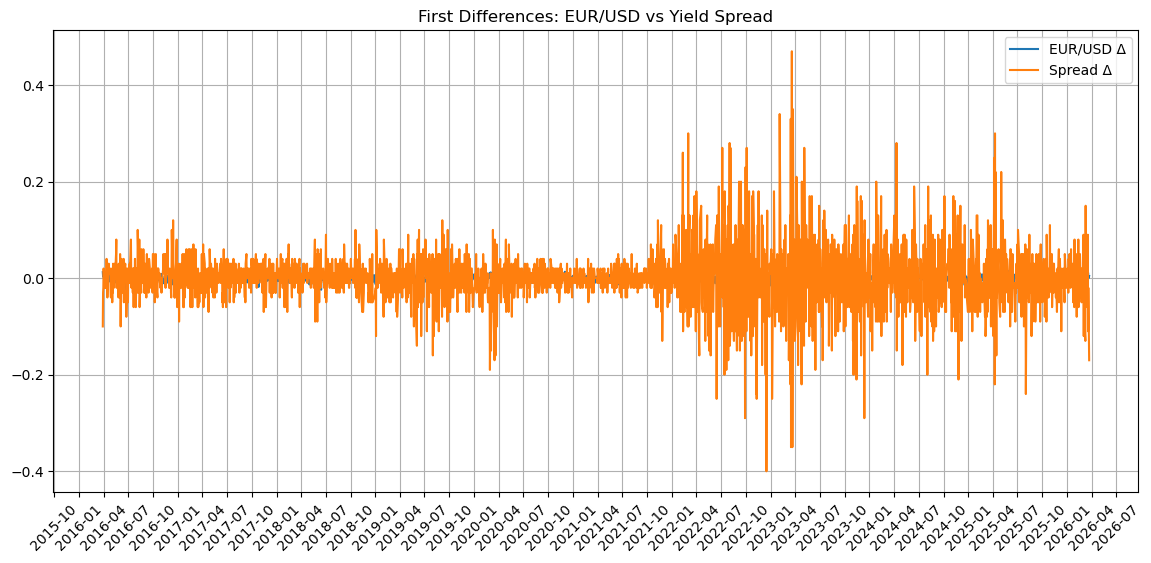

In [10]:
# Plot with raw data of first difference EURUSD , YieldSpread

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(ds_merged["Date"], ds_merged["EURUSD_diff"], label="EUR/USD Δ")
ax.plot(ds_merged["Date"], ds_merged["Spread_diff"], label="Spread Δ")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
ax.set_title("First Differences: EUR/USD vs Yield Spread")
ax.grid()

plt.show()

$$
\begin{array}{l}
\quad\quad\quad \textbf{Technical point of view:} \\[1em]
\quad\quad\quad\quad \bullet \ \text{Co-movement between the two series is } \textbf{not immediately observable} \\
\quad\quad\quad\quad \bullet \ \text{The dominance of spread volatility masks potential relationships} \\[1em]
\quad\quad\quad \text{Visual inspection alone is insufficient to assess the strength or direction of the relationship.} \\[1em]
\quad\quad\quad \text{This justifies:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{normalization (Z-scores)} \\
\quad\quad\quad\quad \bullet \ \text{correlation analysis} \\
\quad\quad\quad\quad \bullet \ \text{rolling correlation} \\[2em]
\quad\quad\quad \textbf{From a macro-financial perspective:} \\[1em]
\quad\quad\quad \text{Changes in the yield spread reflect shifts in relative monetary policy expectations.} \\[1em]
\quad\quad\quad \text{These shifts should theoretically influence } \textbf{EUR/USD}. \\[1em]
\quad\quad\quad \text{However, the figure suggests that:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{The transmission mechanism is not instantaneous} \\
\quad\quad\quad\quad \bullet \ \text{It may involve lags, asymmetries, or nonlinearities} \\
\end{array}
$$

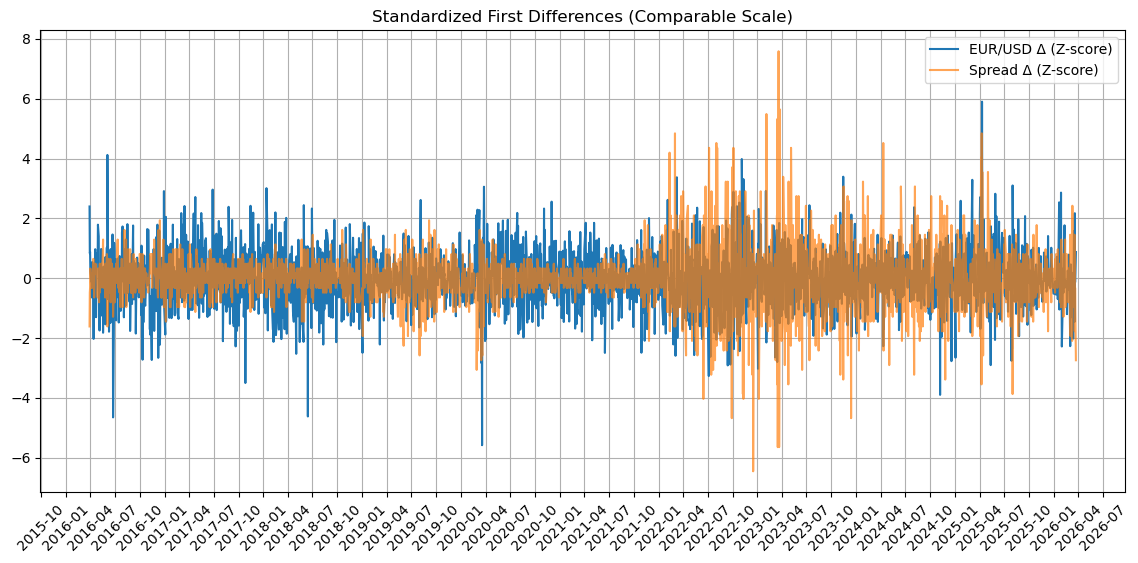

In [11]:
# Standardize (Z-score)
ds_merged["Spread_diff_Z"] = (ds_merged["Spread_diff"] - ds_merged["Spread_diff"].mean()) / ds_merged["Spread_diff"].std()
ds_merged["EURUSD_diff_Z"] = (ds_merged["EURUSD_diff"] - ds_merged["EURUSD_diff"].mean()) / ds_merged["EURUSD_diff"].std()

# Plot


fig, ax = plt.subplots(figsize=(14,6))

ax.plot(ds_merged["Date"], ds_merged["EURUSD_diff_Z"], label="EUR/USD Δ (Z-score)")
ax.plot(ds_merged["Date"], ds_merged["Spread_diff_Z"], label="Spread Δ (Z-score)", alpha=0.7)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.legend()
plt.title("Standardized First Differences (Comparable Scale)")
plt.grid()
plt.show()

$$
\begin{array}{l}
\quad\quad\quad \text{The figure presents the standardized first differences (Z-scores) of:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \Delta \text{EUR/USD} \\
\quad\quad\quad\quad \bullet \ \Delta \text{Spread} \\[1.5em]
\quad\quad\quad \text{Their standardization:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Z-score of } \Delta \text{EUR/USD}_t \\
\quad\quad\quad\quad \bullet \ \text{Z-score of } \Delta \text{Spread}_t \\[1.5em]
\quad\quad\quad\quad\quad\quad Z_t = \frac{X_t - \mu}{\sigma} \\[2em]
\quad\quad\quad \textbf{ensures both series are expressed in terms of standard deviations from their} \\
\quad\quad\quad \textbf{respective means, allowing direct comparison of their relative fluctuations.} \\[1em]
\quad\quad\quad \text{Thus, the graph reflects } \textbf{normalized changes} \text{, not absolute ones.} \\[1.5em]
\quad\quad\quad \text{The standardized representation allows a clearer visual assessment of } \textbf{co-movement:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Periods where both series move in the } \textbf{same direction} \text{ suggest positive} \\
\quad\quad\quad\quad \quad \text{contemporaneous association} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Periods of } \textbf{opposite movement} \text{ indicate negative dependence} \\[1em]
\quad\quad\quad \textbf{However:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{The relationship appears } \textbf{intermittent and unstable} \\
\quad\quad\quad\quad \bullet \ \text{No persistent one-to-one alignment is observed} \\[1em]
\quad\quad\quad \text{The correlation between the yield spread and EUR/USD is } \textbf{time-varying and potentially} \\
\quad\quad\quad \textbf{nonlinear}. \\
\end{array}
$$

$$
\begin{array}{l}
\quad\quad\quad \text{There appears to be a correlation between the two variables, consistent with evidence} \\
\quad\quad\quad \text{reported in the financial literature.} \\[1em]
\quad\quad\quad \text{The next step is to determine whether this relationship is } \textbf{statistically significant} \\
\quad\quad\quad \text{rather than driven by random noise.} \\[1em]
\quad\quad\quad \text{This is achieved by computing the } \textbf{Pearson correlation coefficient} \text{ and evaluating its} \\
\quad\quad\quad \text{associated p-value.} \\[2em]
\quad\quad\quad \textbf{Pearson correlation coefficient } r : \\[1em]
\quad\quad\quad\quad \text{Measures strength and direction of linear relationship} \\[0.5em]
\quad\quad\quad r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \, \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}} \\[2em]
\quad\quad\quad\quad \bullet \quad r \in [-1,1] \\[0.5em]
\quad\quad\quad\quad \bullet \quad r > 0 \ \rightarrow \ \text{same direction} \\[0.5em]
\quad\quad\quad\quad \bullet \quad r < 0 \ \rightarrow \ \text{opposite direction} \\[2em]
\quad\quad\quad\quad \bullet \quad r  \approx 0 \ \rightarrow \ \text{no linear link} \\[2em]
\quad\quad\quad \textbf{p-value (significance of } r\textbf{)}\\[1em]
\quad\quad\quad \text{Formula:} \\[0.5em]
\quad\quad\quad\quad t = \frac{r \sqrt{n-2}}{\sqrt{1 - r^2}} \\[0.5em]
\quad\quad\quad \text{Meaning:} \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \text{Null hypothesis: } H_0: \ \rho = 0 \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \text{Alternative hypothesis: } H_1: \ \rho \neq 0 \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \rho \ (\text{rho}) \ \rightarrow \ \text{true population correlation} \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \rho = 0 \ \rightarrow \ \textbf{no real relationship} \\[0.5em]
\quad\quad\quad\quad\quad \text{It can be read: "The true (real) correlation between the two variables is zero.”} \\[1em]
\end{array}
$$

In [15]:
clean_data = ds_merged[["Date", "EURUSD_diff", "Spread_diff"]].dropna()

corr, p = pearsonr(clean_data["EURUSD_diff"], clean_data["Spread_diff"])

print(corr, p)

-0.25974713529320625 4.719256490931512e-39


$$
\begin{array}{l}
\quad\quad\quad \text{The Pearson correlation between first differences of the EUR/USD exchange rate and the} \\
\quad\quad\quad \text{yield spread is approximately } \textbf{-0.26}. \\[1em]
\quad\quad\quad \text{This relationship is } \textbf{statistically significant} \text{ at conventional levels } (p < 0.001), \\
\quad\quad\quad \text{indicating that the observed correlation is unlikely to be due to random variation.} \\[1em]
\quad\quad\quad \text{However, the magnitude of the correlation remains } \textbf{moderate}, \text{ suggesting that the} \\
\quad\quad\quad \text{yield spread explains only a limited portion of short-term exchange rate movements.} \\[1em]
\quad\quad\quad \text{The negative sign of the correlation is consistent with } \textbf{theoretical expectations}, \text{ as an} \\
\quad\quad\quad \text{increase in the yield spread (favoring US assets) is associated with a depreciation of the} \\
\quad\quad\quad \text{euro against the US dollar.} \\
\end{array}
$$

$$
\begin{array}{1}
\quad\quad\quad\quad\quad \Large \textbf{PERIOD\ DECOMPOSITION} \\[3em]
\end{array}
$$

$$
\begin{array}{l}
\quad\quad\quad \text{To obtain a more nuanced understanding of the relationship between these two variables, it is} \\
\quad\quad\quad \text{methodologically appropriate to decompose the overall period (2016--2026) into several} \\
\quad\quad\quad \text{subperiods. This segmentation allows for a more precise identification of their } \textbf{dynamic} \\
\quad\quad\quad \textbf{interdependencies} \text{ and facilitates the detection of potential structural changes in their relationship.} \\[1em]
\quad\quad\quad \text{Such an approach is particularly relevant in the presence of } \textbf{major exogenous shocks} \text{---} \\
\quad\quad\quad \text{such as geopolitical conflicts or global crises---which may temporarily distort or even override} \\
\quad\quad\quad \text{the underlying macroeconomic mechanisms governing the variables.} \\[1em]
\quad\quad\quad \text{Accordingly, the analysis is structured around the following subperiods:}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{Period 1: 2016 -- Feb 2020} \\[0.3em]
\quad \textit{Pre-COVID / Low-rate environment} \\[0.5em]
\quad\quad \bullet \ \text{Stable monetary policy} \\
\quad\quad \bullet \ \text{Low inflation} \\
\quad\quad \bullet \ \text{Weak yield spread dynamics} \\[1.2em]
\quad \textbf{Period 2: Mar 2020 -- Dec 2021} \\[0.3em]
\quad \textit{COVID shock \& policy intervention} \\[0.5em]
\quad\quad \bullet \ \text{Massive central bank stimulus} \\
\quad\quad \bullet \ \text{Near-zero rates} \\
\quad\quad \bullet \ \text{Distorted yield signals} \\[1.2em]
\quad \textbf{Period 3: 2022 -- 2026} \\[0.3em]
\quad \textit{Wars \& Inflation shock \& monetary tightening} \\[0.5em]
\quad\quad \bullet \ \text{Fed hiking aggressively} \\
\quad\quad \bullet \ \text{ECB lagging initially} \\
\quad\quad \bullet \ \text{Strong yield spread movements} \\
\quad\quad \bullet \ \text{Geopolitical shocks (Ukraine, energy crisis)}
\end{array}
$$

In [16]:
clean_data

,Date,EURUSD_diff,Spread_diff
1,2016-03-29,0.01248,-0.10
2,2016-03-30,0.00435,-0.03
3,2016-03-31,0.00458,-0.02
4,2016-04-01,0.00114,0.02
5,2016-04-04,-0.00034,-0.02
...,...,...,...
2445,2026-03-17,0.00404,0.02
2446,2026-03-18,-0.00755,0.09
2447,2026-03-19,0.01131,-0.11
2448,2026-03-20,-0.00069,-0.02


In [25]:
#temporal segmentation, three periods
p_precovid=clean_data[clean_data["Date"]<"2020-03-01"]
p_covid=clean_data[
    (clean_data["Date"]>="2020-03-01") &
    (clean_data["Date"]<="2021-12-31")
]
p_wartime=clean_data[clean_data["Date"]>="2022-01-01"]




In [27]:
# correlation coefficient an dp-value for pre covid period from 2016-03 till 2020-03-01
corr, p = pearsonr(p_precovid["EURUSD_diff"], p_precovid["Spread_diff"])

print(corr, p)

-0.23778549666611068 8.564357552783145e-14


In [28]:
# correlation coefficient an dp-value for covid period from 2020-03 till 2022-12-31
corr, p = pearsonr(p_covid["EURUSD_diff"], p_covid["Spread_diff"])

print(corr, p)

-0.17416341206180594 0.00019521863622899333


In [29]:
# correlation coefficient an dp-value for wartime period from 2022-01 till 2026-03
corr, p = pearsonr(p_wartime["EURUSD_diff"], p_wartime["Spread_diff"])

print(corr, p)

-0.3105474497827252 1.2770672525280801e-24


$$
\begin{array}{lccc}
\quad \textbf{Period} & \textbf{Correlation (r)} & \textbf{p-value} & \textbf{Interpretation} \\[0.5em]
\hline \\[-0.3em]
\quad \text{Pre-COVID} & -0.238 & 8.56 \times 10^{-14} & \text{Moderate negative} \\[0.5em]
\quad \text{COVID} & -0.174 & 1.95 \times 10^{-4} & \text{Weak negative} \\[0.5em]
\quad \text{Wartime} & -0.311 & 1.27 \times 10^{-24} & \text{Stronger negative} \\[0.5em]
\quad \textbf{Full Period (2016--2026)} & \textbf{-0.260} & \mathbf{4.72 \times 10^{-39}} & \textbf{Moderate negative}
\end{array}
$$

$$
\begin{array}{l}
\quad\quad\quad\quad\quad\quad\quad \Large \textbf{ECONOMIC INTERPRETATIONS} \\[4em]
\quad \text{The results indicate a statistically significant negative correlation between changes in the} \\
\quad \text{EUR/USD exchange rate and changes in the yield spread across all considered periods.} \\
\quad \text{However, this relationship exhibits substantial time variation, suggesting the presence of} \\
\quad \textbf{regime-dependent dynamics}. \\[1.2em]
\quad \textbf{Pre-COVID period} \\[0.5em]
\quad \text{During the pre-COVID period, the correlation is moderately negative } (r = -0.238), \\
\quad \text{indicating a stable inverse relationship between the exchange rate and the yield spread.} \\
\quad \text{This is consistent with standard macro-financial theory, whereby an increase in the} \\
\quad \text{US--EU yield differential tends to appreciate the US dollar relative to the euro.} \\[1.2em]
\quad \textbf{COVID period} \\[0.5em]
\quad \text{During the COVID period, the correlation weakens } (r = -0.174), \text{ although it remains} \\
\quad \text{statistically significant. This attenuation suggests that conventional interest rate} \\
\quad \text{differentials played a less dominant role, likely overshadowed by extraordinary factors such} \\
\quad \text{as global risk aversion, monetary policy interventions, and liquidity shocks.} \\[1em]
\quad \textbf{Wartime period (post-2022)} \\[0.5em]
\quad \text{In the wartime period, the correlation strengthens markedly } (r = -0.311), \text{ indicating a more} \\
\quad \text{pronounced sensitivity of the exchange rate to yield differentials. This may reflect the} \\
\quad \text{re-emergence of interest rate expectations as a key driver, alongside heightened geopolitical} \\
\quad \text{risk and energy market disruptions affecting the euro area.} \\[1.2em]
\quad \text{Over the full sample (2016--2026), the correlation remains moderately negative } (r = -0.260), \\
\quad \text{but this aggregate measure conceals significant heterogeneity across subperiods. The} \\
\quad \text{variation in correlation strength highlights the importance of } \textbf{temporal segmentation} \\
\quad \text{when analyzing exchange rate determinants.}
\end{array}
$$